# Car Price Prediction using Machine Learning

## Project Overview
This project builds a **Random Forest Regression** model to predict the selling price of used cars based on multiple vehicle attributes. It is developed as part of the **Oasis Infobyte Data Science Internship — Task 3**.

## Objective
- Analyze key factors that influence the resale value of a car.
- Engineer meaningful features and preprocess the dataset for modeling.
- Train and evaluate a regression model to accurately predict car prices.

## Dataset
The dataset contains **301 records** with 9 attributes including car name, year, selling price, present price, kilometers driven, fuel type, seller type, transmission, and number of previous owners.

## Expected Outcome
A well-performing regression model with high R² score, along with insights into the most important features affecting car prices.

## 1. Importing Libraries
Load all required libraries for data manipulation, visualization, model building, evaluation, and persistence.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

## 2. Loading Dataset
Read the car dataset from the CSV file and display the first few records to verify successful loading.

In [2]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\OASIS INFOBYTE INTERNSHIP\TASK 3\DATASET\car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Dataset Overview
Examine the shape, column data types, and statistical summary of the dataset.
This helps identify numerical ranges, data types, and potential anomalies early on.

In [3]:
print(df.shape)

df.info()

df.describe()

(301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 4. Missing Value Analysis
Check for null or missing values across all columns.
Handling missing data is critical to prevent errors and bias during model training.

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## 5. Data Preprocessing — Categorical Exploration
Inspect the unique categories in categorical columns (`Fuel_Type`, `Selling_type`, `Transmission`).
Understanding category distribution guides the encoding strategy used later.

In [5]:
print(df["Fuel_Type"].unique())

print(df["Selling_type"].unique())

print(df["Transmission"].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


## 6. Feature Engineering
Create a new feature `Car_Age` by subtracting the manufacturing year from the current year.
Car age is a stronger predictor of depreciation than the raw year value.

In [6]:
df["Current_Year"] = 2025

df["Car_Age"] = df["Current_Year"] - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Current_Year,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2025,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2025,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2025,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2025,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2025,11


## 7. Data Preprocessing — Column Dropping
Remove columns that are no longer needed: `Car_Name`, `Year`, and `Current_Year`.
These columns are either non-numeric identifiers or have been replaced by engineered features.

In [7]:
df.drop(
    ["Car_Name",
     "Year",
     "Current_Year"],
    axis=1,
    inplace=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


## 8. Data Preprocessing — One-Hot Encoding
Convert categorical variables into binary indicator columns using `pd.get_dummies()`.
The `drop_first=True` parameter avoids multicollinearity by dropping one category per feature.

In [8]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


## 9. Correlation Analysis
Visualize feature correlations using a heatmap to identify strong linear relationships.
This helps confirm which features are most relevant to the target variable `Selling_Price`.

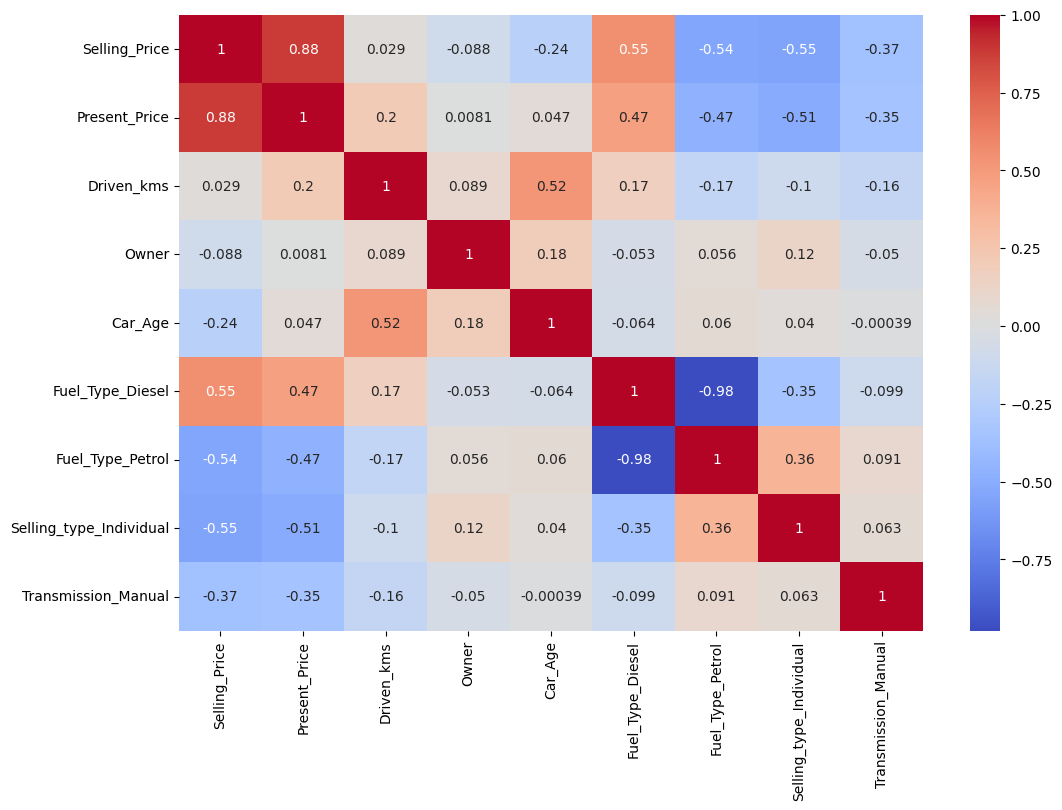

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## 10. Train-Test Split
Separate features (`X`) and target (`y`), then split the data into 80% training and 20% testing sets.
This ensures an unbiased evaluation of model performance on unseen data.

In [10]:
X = df.drop(
    "Selling_Price",
    axis=1
)

y = df["Selling_Price"]

print(X.shape)
print(y.shape)

(301, 8)
(301,)


Split the dataset using `train_test_split` with `random_state=42` for reproducibility.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


## 11. Model Training
Train a **Random Forest Regressor** with 100 estimators on the training data.
Random Forest is an ensemble method that reduces overfitting by averaging multiple decision trees.

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


## 12. Prediction Analysis
Generate predictions on the test set and preview the first 10 predicted values.
This provides an initial qualitative check before computing formal metrics.

In [13]:
predictions = model.predict(X_test)

predictions[:10]

array([ 0.4438, 10.9098,  4.9315,  0.2159,  7.7988,  6.2535,  1.1065,
        0.5876,  0.469 ,  6.896 ])

## 13. Model Evaluation
Evaluate model accuracy using **MAE**, **MSE**, **RMSE**, and **R² Score**.
A high R² (close to 1) and low error values indicate a well-fitted model.

In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.6368655737704919
MSE : 0.9339387986885236
RMSE: 0.9664050903676592
R2 Score: 0.9594566919773236


## 14. Actual vs Predicted Prices
Plot actual vs. predicted selling prices to visually assess model performance.
Points closer to the diagonal line indicate more accurate predictions.

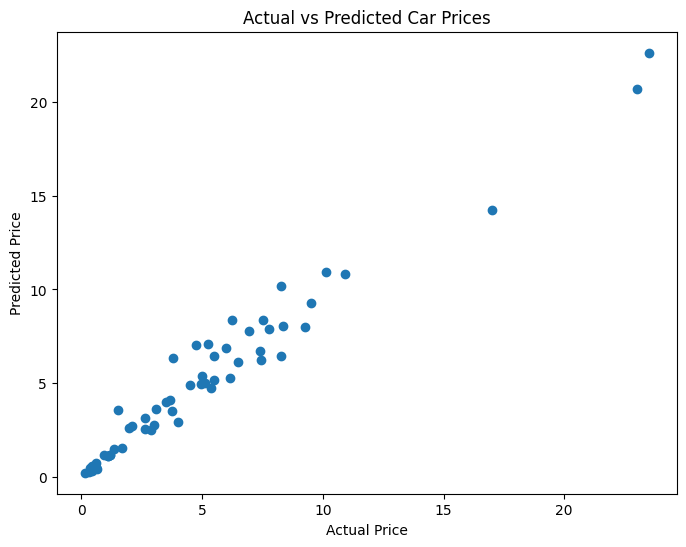

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Car Prices"
)

plt.show()

## 15. Feature Importance
Display the relative importance of each feature as determined by the Random Forest model.
This reveals which attributes have the greatest impact on price prediction.

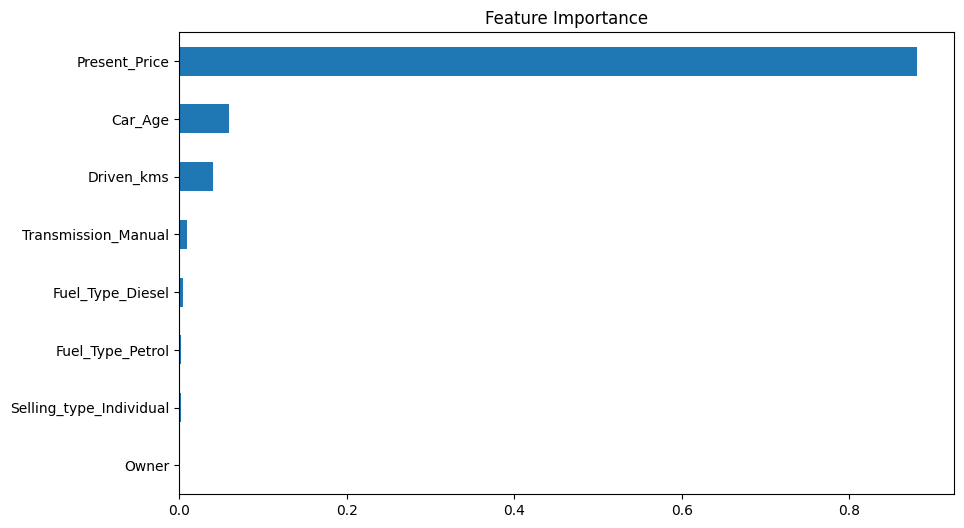

In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Feature Importance"
)

plt.show()

## 16. Model Saving
Persist the trained model to disk using `joblib` so it can be loaded for future predictions without retraining.

In [18]:
joblib.dump(
    model,
    "../Model/car_price_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## 17. Conclusion

**Model Performance:**  
The Random Forest Regressor achieved an **R² score of ~0.96**, indicating the model explains approximately 96% of the variance in car selling prices.

**Key Influencing Features:**  
- `Present_Price` (current showroom price) is the most dominant predictor.
- `Car_Age` and `Driven_kms` also significantly affect resale value.

**Overall Outcome:**  
The project successfully demonstrates an end-to-end machine learning pipeline — from data loading and preprocessing to model training, evaluation, and saving.

**Future Improvements:**  
- Experiment with hyperparameter tuning (e.g., GridSearchCV) for better accuracy.
- Try additional algorithms such as Gradient Boosting or XGBoost for comparison.
- Incorporate a larger, more diverse dataset to improve generalization.